# 1. Install + Import Requirements

In [152]:
%pip install mujoco mediapy numpy

import mujoco
import mediapy as media
import numpy as np

%pip install ultralytics

from ultralytics import YOLO

%pip install opencv-python


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 2. Define MuJoCo XML Scene

In [153]:
xml_string = """
<mujoco>
  <compiler angle="degree"/>
  
  <asset>
    <!-- Define the .obj files as mesh assets -->
    <mesh name="mug_mesh" file="mug.obj"/>
    <mesh name="can_opener_mesh" file="can_opener.obj"/>
    <mesh name="action_fig_mesh" file="action_fig.obj"/>
    <mesh name="shoe_mesh" file="shoe.obj"/>
  </asset>

  <worldbody>
    <light pos="0 0 1.5" dir="0 0 -1" directional="true" diffuse="0.8 0.8 0.8"/>
    <geom type="plane" size="1 1 0.1" rgba="0.9 0.9 0.9 1"/>
    
    <!-- Object: Mug -->
    <body name="mug" pos="0 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="mug_mesh" rgba="0.8 0.2 0.2 1"/>
    </body>
    
    <!-- Object: Can Opener -->
    <body name="can_opener" pos="0.1 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="can_opener_mesh" rgba="0.2 0.8 0.2 1"/>
    </body>
    
    <!-- Object: Action Figure -->
    <body name="action_fig" pos="-0.1 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="action_fig_mesh" rgba="0.2 0.2 0.8 1"/>
    </body>
    
    <!-- Object: Shoe -->
    <body name="shoe" pos="0 0.1 0.1">
      <freejoint/>
      <geom type="mesh" mesh="shoe_mesh" rgba="0.5 0.5 0.5 1"/>
    </body>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml_string)
data = mujoco.MjData(model)

# 3. Generate Training Data for YOLO Finetuning
This will be labelled bounding boxes from openCV of the objects initialized to random transforms

In [154]:
import os
import cv2
import yaml

skip_perception_training = os.path.exists("runs/obb/current")

dataset_dir = "datasets/mujoco_obb"

# all objects have class 0, because we dont care what they are - just need to sweep them.
classes = {"mug": 0, "can_opener": 0, "action_fig": 0, "shoe": 0}
object_names = list(classes.keys())         # must be after classes dict

# use MuJoCo's built in segmenter
seg_renderer = mujoco.Renderer(model, 480, 640)
seg_renderer.enable_segmentation_rendering()
renderer = mujoco.Renderer(model, 480, 640)  # must be after seg_renderer

if skip_perception_training:
    print("Skipping dataset generation (using runs/obb/current).")
else:

    # set up datasets
    os.makedirs(f"{dataset_dir}/images/train", exist_ok=True)
    os.makedirs(f"{dataset_dir}/labels/train", exist_ok=True)

    # generate 100 training images
    print("Generating synthetic data. This will take a moment...")
    frames_to_generate = 100
    vis_img = None

    for i in range(frames_to_generate):
        # random positions and rotations for each frame
        for obj_name in object_names:
            body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
            
            rand_x, rand_y = np.random.uniform(-0.4, 0.4, size=2)

            # add random rotation
            rand_angle = np.random.uniform(0, 2 * np.pi)
            q_z = [np.cos(rand_angle/2), 0, 0, np.sin(rand_angle/2)]
            
            qpos_start = model.jnt_qposadr[model.body_jntadr[body_id]]
            data.qpos[qpos_start:qpos_start+3] = [rand_x, rand_y, 0.2]
            data.qpos[qpos_start+3:qpos_start+7] = q_z
            
        mujoco.mj_forward(model, data)
        num_steps = np.random.randint(10, 100)  # let the objects fall a random amount, would like mid-air support
        for _ in range(num_steps):  # roll out physics
            mujoco.mj_step(model, data)
            
        # render scene and segments
        renderer.update_scene(data)
        rgb_img = renderer.render()
        
        seg_renderer.update_scene(data)
        seg_img = seg_renderer.render()
        
        img_h, img_w = rgb_img.shape[:2]
        
        # save the last frame to see if the model is working correctly
        if i == frames_to_generate - 1:
            vis_img = rgb_img.copy()

        # now we can make the label for this data point
        label_file = open(f"{dataset_dir}/labels/train/frame_{i}.txt", "w")
        
        for obj_name, class_idx in classes.items():
            body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
            
            # get the MuJoCo geoms
            geom_start = model.body_geomadr[body_id]
            geom_num = model.body_geomnum[body_id]
            
            # create binary mask for this object
            mask = np.isin(seg_img[:, :, 0], range(geom_start, geom_start + geom_num)).astype(np.uint8) * 255
            
            # use openCV to get the bounding box
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                c = max(contours, key=cv2.contourArea)
                # only save the bounding box if not obscured or offscreen
                if cv2.contourArea(c) > 50: 
                    # minAreaRect gets the box corners
                    rect = cv2.minAreaRect(c)
                    box = cv2.boxPoints(rect)
                    
                    if vis_img is not None:
                        # draw a green box in the visualization image for us to see if its working
                        cv2.drawContours(vis_img, [np.int32(box)], 0, (0, 255, 0), 2)
                    
                    # must normalize coordinates between 0.0 and 1.0 to work in YOLO
                    box[:, 0] /= img_w
                    box[:, 1] /= img_h
                    
                    # yolo format: "class_idx x1 y1 x2 y2 x3 y3 x4 y4"
                    label_str = " ".join([f"{coord:.5f}" for coordinate in box for coord in coordinate])
                    label_file.write(f"{class_idx} {label_str}\n")
                    
        label_file.close()
        
        # create image for this data point, opencv uses BGR format
        cv2.imwrite(f"{dataset_dir}/images/train/frame_{i}.jpg", cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))

    print("Synthetic Dataset Generation Complete!")

    # view the final frame with the visualization as a sanity check
    if vis_img is not None:
        print("Visual sanity check:")
        media.show_image(vis_img)

Skipping dataset generation (using runs/obb/current).


# 4. Fine Tune YOLO
Use the data set of labelled images we just generated.

In [155]:
if skip_perception_training:
    print("Skipping YOLO training (using runs/obb/current).")
else:
    # ultralytics needs dataset.yaml, so make it
    yaml_config = {
        'path': os.path.abspath(dataset_dir),
        'train': 'images/train',
        'val': 'images/train', # WILL CHANGE: need to use actual validation set
        # only one class
        'names': {0: "object"}
    }

    with open('mujoco_dataset.yaml', 'w') as f:
        yaml.dump(yaml_config, f)

    # import base YOLO
    model_obb = YOLO('yolov8n-obb.pt')

    # train
    results = model_obb.train(data='mujoco_dataset.yaml', epochs=25, imgsz=640, device="cpu", verbose=False)

    print("Training finished!")

Skipping YOLO training (using runs/obb/current).


# 4. Test Perception Module

In [156]:
class PerceptionModule:
    """
    Combines YOLO 2D Object Detection with Depth maps to estimate
    the 3D transform (position and orientation) of detected objects
    relative to the camera.
    """
    def __init__(self, weights_path, fovy_degrees=45.0):
        self.model = YOLO(weights_path)
        # default camera has 45 degree vertical field of view
        self.fovy_degrees = fovy_degrees

    def _rotation_from_obb(self, rotation_rad):
        # Build a camera-frame rotation from the OBB angle in the image plane.
        c = float(np.cos(rotation_rad))
        s = float(np.sin(rotation_rad))
        x_axis = np.array([c, s, 0.0], dtype=np.float32)
        z_axis = np.array([0.0, 0.0, -1.0], dtype=np.float32)
        y_axis = np.cross(z_axis, x_axis)
        x_axis /= np.linalg.norm(x_axis) + 1e-8
        y_axis /= np.linalg.norm(y_axis) + 1e-8
        z_axis = np.cross(x_axis, y_axis)
        return np.stack([x_axis, y_axis, z_axis], axis=1)

    def get_transforms(self, rgb_image, depth_image, model=None, camera=None):
        # run model
        results = self.model(rgb_image, verbose=False)[0]

        objects = []
        if results.obb is not None:
            h, w = rgb_image.shape[:2]

            # get camera intrinsics
            fovy_rad = np.deg2rad(self.fovy_degrees)
            fy = (h / 2.0) / np.tan(fovy_rad / 2.0)
            fx = fy
            cx = w / 2.0
            cy = h / 2.0

            # Mirror camera-frame axes to match the overhead camera frame in the scene.
            mirror_mat = np.diag([1.0, -1.0, -1.0]).astype(np.float32)

            cam_pos = None
            cam_R = None
            if model is not None and camera is not None:
                cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, camera)
                if cam_id >= 0:
                    cam_pos = model.cam_pos[cam_id].copy()
                    cam_quat = model.cam_quat[cam_id].copy()
                    cam_mat = np.zeros(9, dtype=np.float64)
                    mujoco.mju_quat2Mat(cam_mat, cam_quat)
                    cam_R = cam_mat.reshape(3, 3)

            for box in results.obb:
                # get OBB parameters
                x_center, y_center, width, height, rotation = box.xywhr[0].cpu().numpy()
                class_id = int(box.cls[0].item())
                confidence = float(box.conf[0].item())

                # get depth at each object's center
                u = int(np.clip(x_center, 0, w - 1))
                v = int(np.clip(y_center, 0, h - 1))
                z = depth_image[v, u]

                # use deprojection formula:
                x = (u - cx) * z / fx
                y = (v - cy) * z / fy
                pos_cam = mirror_mat @ np.array([x, y, z], dtype=np.float32)

                rot_cam = self._rotation_from_obb(rotation)
                rot_cam = mirror_mat @ rot_cam
                tf_cam = np.eye(4, dtype=np.float32)
                tf_cam[:3, :3] = rot_cam
                tf_cam[:3, 3] = pos_cam

                transform = {
                    "class": results.names[class_id],
                    "position_camera_frame": pos_cam,
                    "rotation_rad": float(rotation),
                    "rotation_camera_frame": rot_cam,
                    "transform_camera_frame": tf_cam,
                    "confidence": confidence,
                    "pixel_u": u,
                    "pixel_v": v
                }
                if cam_pos is not None and cam_R is not None:
                    pos_world = cam_pos + cam_R @ pos_cam
                    rot_world = cam_R @ rot_cam
                    tf_world = np.eye(4, dtype=np.float32)
                    tf_world[:3, :3] = rot_world
                    tf_world[:3, 3] = pos_world
                    transform["position_world"] = pos_world
                    transform["rotation_world"] = rot_world
                    transform["transform_world"] = tf_world
                objects.append(transform)

        # return the list of object transforms and the annotated image
        return objects, results.plot()

# 5. Scene with Robot (Broom + Franka Panda)
Build the combined MuJoCo scene using `mujoco.MjSpec`.

The broom mesh is generated **programmatically** — correct dimensions,
zero licensing issues, no external conversion needed.

In [157]:
import subprocess, os

# ── 0. Generate broom.obj if not already present ──────────────────────────
def _make_broom_obj(path, n_seg=20):
    import numpy as np
    verts, faces = [], []
    r, hz0, hz1 = 0.015, 0.05, 0.75
    for i in range(n_seg):
        a = 2*np.pi*i/n_seg; verts.append((r*np.cos(a), r*np.sin(a), hz0))
    for i in range(n_seg):
        a = 2*np.pi*i/n_seg; verts.append((r*np.cos(a), r*np.sin(a), hz1))
    verts += [(0,0,hz0),(0,0,hz1)]
    bc, tc = 2*n_seg+1, 2*n_seg+2
    for i in range(n_seg):
        v0,v1,v2,v3 = i+1, i%n_seg+2, n_seg+i%n_seg+2, n_seg+i+1
        faces += [(v0,v1,v2),(v0,v2,v3)]
    for i in range(n_seg): faces.append((bc, i%n_seg+2, i+1))
    for i in range(n_seg): faces.append((tc, n_seg+i+1, n_seg+i%n_seg+2))
    bx,by,bz0,bz1 = 0.12,0.03,0.0,0.05; o = len(verts)+1
    for bv in [(-bx,-by,bz0),(bx,-by,bz0),(bx,by,bz0),(-bx,by,bz0),
               (-bx,-by,bz1),(bx,-by,bz1),(bx,by,bz1),(-bx,by,bz1)]:
        verts.append(bv)
    faces += [(o,o+2,o+1),(o,o+3,o+2),(o+4,o+5,o+6),(o+4,o+6,o+7),
              (o,o+1,o+5),(o,o+5,o+4),(o+1,o+2,o+6),(o+1,o+6,o+5),
              (o+2,o+3,o+7),(o+2,o+7,o+6),(o+3,o,o+4),(o+3,o+4,o+7)]
    with open(path,"w") as f:
        f.write("# Parametric broom: handle r=0.015m z=[0.05,0.75]; head 0.24x0.06x0.05m\n")
        for v in verts: f.write(f"v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n")
        for fc in faces: f.write(f"f {fc[0]} {fc[1]} {fc[2]}\n")
    print(f"Generated {path}  ({len(verts)} verts, {len(faces)} faces)")

if not os.path.exists("broom.obj"):
    _make_broom_obj("broom.obj")
else:
    print("broom.obj already present")

# ── 1. Download Franka Panda model (mujoco_menagerie) ─────────────────────
if not os.path.exists("mujoco_menagerie"):
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/google-deepmind/mujoco_menagerie.git"],
        check=True,
    )

PANDA_XML = "mujoco_menagerie/franka_emika_panda/panda.xml"

# ── 2. Base scene XML (broom mesh included directly) ─────────────────────
# Broom geometry (single geom = visual + collision):
#   Handle : cylinder r=0.015 m,  z = [0.05, 0.75]
#   Head   : box ±0.12 x ±0.03 x [0, 0.05] m
# Grasp point for IK: broom_world_pos + [0, 0, 0.55]  (upper handle)
BASE_XML = """
<mujoco model="sweep_scene">
  <compiler angle="radian"/>
  <option gravity="0 0 -9.81" timestep="0.002" iterations="50" noslip_iterations="10" cone="elliptic"/>
  
  <default>
    <!-- Increase global default friction (sliding, torsional, rolling) -->
    <geom friction="2.0 0.05 0.0001"/>
  </default>

  <asset>
    <mesh name="mug_mesh"        file="mug.obj"/>
    <mesh name="can_opener_mesh" file="can_opener.obj"/>
    <mesh name="action_fig_mesh" file="action_fig.obj"/>
    <mesh name="shoe_mesh"       file="shoe.obj"/>
    <mesh name="broom_mesh"      file="broom.obj"/>
  </asset>
  <worldbody>
    <light pos="0 0 2" dir="0 0 -1" directional="true" diffuse="0.8 0.8 0.8"/>
    <geom type="plane" size="1 1 0.1" rgba="0.9 0.9 0.9 1"/>
    <!-- Fixed overhead camera used by PerceptionModule -->
    <camera name="overhead_cam" pos="0 0 1.5" euler="0 0 0" fovy="45"/>
    <!-- Broom: freejoint so it can be grasped and lifted -->
    <body name="broom" pos="0.3 0.0 0.0">
      <freejoint name="broom_joint"/>
      <!-- Visual geom uses the mesh -->
      <geom name="broom_geom_viz" type="mesh" mesh="broom_mesh"
            rgba="0.65 0.38 0.12 1" contype="0" conaffinity="0"/>
      <!-- Collision geoms using primitives to avoid convex hull artifacts -->
      <!-- Handle: radius 0.015, height extent [0.05, 0.75] -->
      <!-- Center z = (0.75+0.05)/2 = 0.4. Half-length = (0.75-0.05)/2 = 0.35 -->
      <geom name="broom_col_handle" type="cylinder" size="0.015 0.35" pos="0 0 0.4"
            rgba="0 0 0 0" contype="1" conaffinity="3" condim="4" margin="0.003" gap="0.001"
            solref="0.001 1" solimp="0.9 0.95 0.001 0.5 2" friction="6.0 0.1 0.001"/>
      <!-- Head: box from x=-0.12..0.12, y=-0.03..0.03, z=0..0.05 -->
      <!-- Center z=0.025. Half-size: 0.12 0.03 0.025 -->
      <geom name="broom_col_head" type="box" size="0.12 0.03 0.025" pos="0 0 0.025"
            rgba="0 0 0 0" contype="1" conaffinity="3" condim="4" margin="0.003" gap="0.001"
            solref="0.001 1" solimp="0.9 0.95 0.001 0.5 2" friction="5.0 0.1 0.001"/>
    </body>
    <!-- Sweepable objects -->
    <body name="mug"        pos="0    0    0.1"><freejoint/><geom type="mesh" mesh="mug_mesh"        rgba="0.8 0.2 0.2 1"/></body>
    <body name="can_opener" pos="0.1  0    0.1"><freejoint/><geom type="mesh" mesh="can_opener_mesh" rgba="0.2 0.8 0.2 1"/></body>
    <body name="action_fig" pos="-0.1 0    0.1"><freejoint/><geom type="mesh" mesh="action_fig_mesh" rgba="0.2 0.2 0.8 1"/></body>
    <body name="shoe"       pos="0    0.1  0.1"><freejoint/><geom type="mesh" mesh="shoe_mesh"       rgba="0.5 0.5 0.5 1"/></body>
  </worldbody>
</mujoco>
"""

# ── 3. Compose with MjSpec (Panda only — broom is already in BASE_XML) ────
scene_spec = mujoco.MjSpec.from_string(BASE_XML)
panda_spec = mujoco.MjSpec.from_file(PANDA_XML)

# We want torque control across the arm for RL, so let's modify the arm's actuators 
# from position/PD controllers ("general" with biasprm) to pure "motor" elements.
# The gripper (actuator 7) remains in position control so we just adjust the first 7.
for i in range(7):
    act = panda_spec.actuators[i]
    act.set_to_motor()
    act.biastype = mujoco.mjtBias.mjBIAS_NONE
    act.gaintype = mujoco.mjtGain.mjGAIN_FIXED
    act.gainprm = [1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    act.biasprm = [0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    
    # Apply standard Panda torque limits
    act.forcerange = [-87.0, 87.0] if i < 4 else [-12.0, 12.0]

# Increase the physical joint limits of the gripper for simulation (default max is 0.04 per finger)
for j in panda_spec.joints:
    if "finger_joint" in j.name:
        j.range = [0.0, 0.08] # double the opening distance to 8cm per finger (16cm total)

# The generic actuator8 handles the fingers via a split tendon. It is bound to 0-255 ctrlrange.
# We also need to double its implicit position target scaling.
# Original gain was 0.015686... meaning `target_pos = ctrl * 0.04 / 255`
panda_spec.actuators[-1].gainprm[0] = 0.08 / 255.0

# Add EE site to panda hand (menagerie panda.xml has no sites)
panda_hand = next(b for b in panda_spec.bodies if b.name == "hand")

# Disable the palm's single convex hull to allow deep grasping between fingers
for geom in panda_hand.geoms:
    if getattr(getattr(geom, "mesh", None), "name", "") == "hand_c":
        geom.contype = 0
        geom.conaffinity = 0

# Add large gripper plates to the fingers to increase grasp surface area
def find_body_in_spec(spec, name):
    for b in spec.bodies:
        if b.name == name: return b
    return None

for finger_name in ["left_finger", "right_finger"]:
    finger_body = find_body_in_spec(panda_spec, finger_name)
    if finger_body:
        # Check if we didn't already add one by accident
        plate = finger_body.add_geom()
        plate.type = mujoco.mjtGeom.mjGEOM_BOX
        # Local +Y is AWAY from the gap! The gap is in the -Y direction.
        # X is the vertical height of the fingers, Z is the forward reach.
        plate.size = [0.02, 0.004, 0.025]
        plate.pos = [0.0, 0.0, 0.045] # Shifted into the -Y gap
        plate.rgba = [0.2, 0.8, 0.2, 1] # Green plate to easily see it
        plate.friction = [100.0, 0.1, 0.001]
        plate.contype = 2
        plate.conaffinity = 1

        # Add "front" ridge (to stop broom sliding out the front)
        ridge1 = finger_body.add_geom()
        ridge1.type = mujoco.mjtGeom.mjGEOM_BOX
        ridge1.size = [0.02, 0.005, 0.004]  # Tall in X, thick in Y, narrow in Z
        ridge1.pos = [0.0, -0.009, 0.045 + 0.025]   # Front end of the plate (Z) and deep in gap (+Y)
        ridge1.rgba = [0.8, 0.2, 0.2, 1]     # Red to distinguish them
        ridge1.friction = [3.0, 0.1, 0.001]
        ridge1.contype = 2
        ridge1.conaffinity = 1

        # Add "back" ridge (to stop broom sliding back into the hand)
        ridge2 = finger_body.add_geom()
        ridge2.type = mujoco.mjtGeom.mjGEOM_BOX
        ridge2.size = [0.02, 0.005, 0.004]
        ridge2.pos = [0.0, -0.009, 0.045 - 0.025]   # Back end of the plate (Z)
        ridge2.rgba = [0.8, 0.2, 0.2, 1]
        ridge2.friction = [3.0, 0.1, 0.001]
        ridge2.contype = 2
        ridge2.conaffinity = 1

        # Stiffen contacts so the ridges resist interpenetration when the gripper closes.
        for geom in (plate, ridge1, ridge2):
            geom.margin = 0.003
            geom.gap = 0.001
            geom.condim = 4
            geom.solref = [0.005, 1.0]
            geom.solimp = [0.9, 0.95, 0.001, 0.5, 2.0]

ee_site      = panda_hand.add_site()
ee_site.name = "attachment_site"
ee_site.pos  = [0.0, 0.0, 0.1]   # ~10 cm toward fingertips in hand local frame

panda_frame       = scene_spec.worldbody.add_frame()
panda_frame.pos   = [0.7, 0.0, 0.0]
panda_frame.quat  = [0.0, 0.0, 0.0, 1.0] # face the table (π around z)
scene_spec.attach(panda_spec, prefix="panda_", frame=panda_frame)

# ── 4. Compile ─────────────────────────────────────────────────────────────
robot_model = scene_spec.compile()
robot_data  = mujoco.MjData(robot_model)
mujoco.mj_forward(robot_model, robot_data)

# ── 5. Resolve names ──────────────────────────────────────────────────────
site_names = [mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_SITE, i)
              for i in range(robot_model.nsite)]
print("Sites in scene:", site_names)

PANDA_JOINTS  = [f"panda_joint{i}" for i in range(1, 8)]
FINGER_JOINTS = ["panda_finger_joint1", "panda_finger_joint2"]
# Confirm EE_SITE matches one of the printed site names above
EE_SITE = "panda_attachment_site"

print(f"robot_model compiled — nq: {robot_model.nq}, nv: {robot_model.nv}")

broom.obj already present
Sites in scene: ['panda_attachment_site']
robot_model compiled — nq: 44, nv: 39


# 6. Retrain YOLO with Broom Class
Add the broom (class 1) to synthetic training data and retrain YOLOv8-OBB.

In [158]:
import os, cv2, yaml

if skip_perception_training:
    print("Skipping dataset generation and training for broom (using runs/obb/current).")
    BROOM_WEIGHTS = "runs/obb/current/weights/best.pt"
    print(f"BROOM_WEIGHTS: {BROOM_WEIGHTS}")
else:
    DATASET_DIR_R = "datasets/mujoco_obb_with_broom"
    os.makedirs(f"{DATASET_DIR_R}/images/train", exist_ok=True)
    os.makedirs(f"{DATASET_DIR_R}/labels/train", exist_ok=True)

    # Sweepable objects -> class 0, broom -> class 1
    classes_r = {
        "mug": 0, "can_opener": 0, "action_fig": 0, "shoe": 0,
        "broom": 1,
    }

    seg_renderer_r = mujoco.Renderer(robot_model, 480, 640)
    seg_renderer_r.enable_segmentation_rendering()
    renderer_r = mujoco.Renderer(robot_model, 480, 640)

    object_names_r = list(classes_r.keys())

    print("Generating synthetic data with broom. This will take a moment...")
    frames_to_generate = 100
    vis_img_r = None

    for i in range(frames_to_generate):
        for obj_name in object_names_r:
            body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
            rand_x, rand_y = np.random.uniform(-0.35, 0.35, size=2)

            # 80% chance to be relatively upright (z-axis rotation) and 20% fully random
            if np.random.rand() > 0.2:
                rand_yaw = np.random.uniform(0, 2 * np.pi)
                q_rand = np.array([np.cos(rand_yaw/2), 0.0, 0.0, np.sin(rand_yaw/2)])
            else:
                q_rand = np.random.randn(4)
                q_rand /= np.linalg.norm(q_rand)

            qpos_start = robot_model.jnt_qposadr[robot_model.body_jntadr[body_id]]
            robot_data.qpos[qpos_start:qpos_start + 3] = [rand_x, rand_y, 0.15]
            robot_data.qpos[qpos_start + 3:qpos_start + 7] = q_rand

        mujoco.mj_forward(robot_model, robot_data)
        for _ in range(np.random.randint(10, 60)):
            mujoco.mj_step(robot_model, robot_data)

        renderer_r.update_scene(robot_data, camera="overhead_cam")
        rgb_img = renderer_r.render()

        seg_renderer_r.update_scene(robot_data, camera="overhead_cam")
        seg_img = seg_renderer_r.render()

        img_h, img_w = rgb_img.shape[:2]
        if i == frames_to_generate - 1:
            vis_img_r = rgb_img.copy()

        label_file = open(f"{DATASET_DIR_R}/labels/train/frame_{i}.txt", "w")

        for obj_name, class_idx in classes_r.items():
            body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
            geom_start = robot_model.body_geomadr[body_id]
            geom_num = robot_model.body_geomnum[body_id]
            mask = np.isin(seg_img[:, :, 0], range(geom_start, geom_start + geom_num)).astype(np.uint8) * 255
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                c = max(contours, key=cv2.contourArea)
                if cv2.contourArea(c) > 50:
                    rect = cv2.minAreaRect(c)
                    box = cv2.boxPoints(rect)
                    if vis_img_r is not None:
                        cv2.drawContours(vis_img_r, [np.int32(box)], 0, (0, 255, 0), 2)
                    box[:, 0] /= img_w
                    box[:, 1] /= img_h
                    label_str = " ".join([f"{coord:.5f}" for coordinate in box for coord in coordinate])
                    label_file.write(f"{class_idx} {label_str}\n")

        label_file.close()
        cv2.imwrite(f"{DATASET_DIR_R}/images/train/frame_{i}.jpg",
                    cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))

    print("Dataset generation complete!")
    if vis_img_r is not None:
        media.show_image(vis_img_r)

    # Write YAML and retrain
    yaml_config_r = {
        "path": os.path.abspath(DATASET_DIR_R),
        "train": "images/train",
        "val":   "images/train",
        "names": {0: "object", 1: "broom"},
    }
    with open("mujoco_dataset_with_broom.yaml", "w") as f:
        yaml.dump(yaml_config_r, f)

    model_obb_r = YOLO("yolov8n-obb.pt")
    results_r = model_obb_r.train(
        data="mujoco_dataset_with_broom.yaml",
        epochs=50, imgsz=640, device="cpu", verbose=False,
        lr0=0.001, batch=16
    )
    print("Training finished!")

    # Automatically resolve the correct weights path from the completed training run
    BROOM_WEIGHTS = str(results_r.save_dir / "weights" / "best.pt")
    print(f"BROOM_WEIGHTS: {BROOM_WEIGHTS}")

Skipping dataset generation and training for broom (using runs/obb/current).
BROOM_WEIGHTS: runs/obb/current/weights/best.pt


# 6. Grasp Planning

In [159]:
import numpy as np
import mujoco
import cv2
import time

PANDA_READY = np.array([0, -np.pi / 4, 0, -3 * np.pi / 4, 0, np.pi / 2, np.pi / 4], dtype=np.float32)

_IK_WINDOW_NAME = "IK Preview"
_ik_window_ready = False

# --- Joint limits for IK projection ---
def _get_joint_limits(model, joint_names):
    limits = []
    for name in joint_names:
        j_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        lo, hi = model.jnt_range[j_id]
        if lo == 0.0 and hi == 0.0:
            lo, hi = -3.0, 3.0
        limits.append((float(lo), float(hi)))
    return np.array(limits, dtype=np.float32)

JOINT_LIMITS = _get_joint_limits(robot_model, PANDA_JOINTS)

def _clip_q(q, limits):
    return np.minimum(np.maximum(q, limits[:, 0]), limits[:, 1])

# --- Reset scene to model defaults ---
def reset_scene(model, data, arm_qpos=None):
    mujoco.mj_resetData(model, data)
    data.qpos[:] = model.qpos0
    data.qvel[:] = 0.0
    if model.nu > 0:
        data.ctrl[:] = 0.0
    if arm_qpos is not None:
        jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in PANDA_JOINTS]
        qpos_adr = [model.jnt_qposadr[j] for j in jnt_ids]
        for i, adr in enumerate(qpos_adr):
            data.qpos[adr] = arm_qpos[i]
    mujoco.mj_forward(model, data)

# --- Simple settle step to let objects fall ---
def settle_scene(model, data, arm_qpos=None, steps=200):
    jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in PANDA_JOINTS]
    qpos_adr = [model.jnt_qposadr[j] for j in jnt_ids]
    dof_adr = [model.jnt_dofadr[j] for j in jnt_ids]
    for _ in range(steps):
        if arm_qpos is not None:
            for i, adr in enumerate(qpos_adr):
                data.qpos[adr] = arm_qpos[i]
            for d in dof_adr:
                data.qvel[d] = 0.0
        mujoco.mj_step(model, data)
    mujoco.mj_forward(model, data)

# --- Position + orientation IK (damped least squares) ---
def solve_ik_to_site(
    model,
    data,
    site_name,
    target_pos,
    q_init,
    target_rot=None,
    max_iters=400,
    tol=2e-3,
    rot_tol=5e-2,
    damp=5e-3,
    rot_w=0.2,
 ):
    jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in PANDA_JOINTS]
    qpos_adr = [model.jnt_qposadr[j] for j in jnt_ids]
    dof_adr = [model.jnt_dofadr[j] for j in jnt_ids]
    site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, site_name)

    target_pos = target_pos.copy()
    target_pos[2] = max(target_pos[2], 0.05)

    q = q_init.copy()
    for _ in range(max_iters):
        q = _clip_q(q, JOINT_LIMITS)
        for i, adr in enumerate(qpos_adr):
            data.qpos[adr] = q[i]
        mujoco.mj_forward(model, data)

        cur = data.site_xpos[site_id].copy()
        err_pos = target_pos - cur
        if np.linalg.norm(err_pos) > 0.1:
            err_pos = err_pos / np.linalg.norm(err_pos) * 0.1

        jacp = np.zeros((3, model.nv))
        jacr = np.zeros((3, model.nv))
        mujoco.mj_jacSite(model, data, jacp, jacr, site_id)

        rot_err = None
        if target_rot is not None:
            cur_mat = data.site_xmat[site_id].reshape(3, 3)
            quat_cur = np.zeros(4, dtype=np.float64)
            quat_tgt = np.zeros(4, dtype=np.float64)
            mujoco.mju_mat2Quat(quat_cur, cur_mat.flatten())
            mujoco.mju_mat2Quat(quat_tgt, target_rot.flatten())
            quat_err = np.zeros(4, dtype=np.float64)
            quat_cur_conj = quat_cur.copy()
            quat_cur_conj[1:] *= -1.0
            mujoco.mju_mulQuat(quat_err, quat_tgt, quat_cur_conj)
            rot_err = np.zeros(3, dtype=np.float64)
            mujoco.mju_quat2Vel(rot_err, quat_err, 1.0)
            if np.linalg.norm(rot_err) > 0.5:
                rot_err = rot_err / np.linalg.norm(rot_err) * 0.5

        if np.linalg.norm(err_pos) < tol and (rot_err is None or np.linalg.norm(rot_err) < rot_tol):
            return q, True

        if rot_err is not None:
            err = np.concatenate([err_pos, rot_w * rot_err])
            J = np.vstack([jacp[:, dof_adr], rot_w * jacr[:, dof_adr]])
            A = J @ J.T + damp * np.eye(6)
        else:
            err = err_pos
            J = jacp[:, dof_adr]
            A = J @ J.T + damp * np.eye(3)

        dq = J.T @ np.linalg.solve(A, err)
        q = q + 0.5 * dq

    return q, False

def _get_arm_actuator_ids(model, joint_names):
    jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in joint_names]
    jnt_to_idx = {jid: i for i, jid in enumerate(jnt_ids)}
    act_ids = []
    for act_id in range(model.nu):
        joint_id = int(model.actuator_trnid[act_id, 0])
        if joint_id in jnt_to_idx:
            act_ids.append((jnt_to_idx[joint_id], act_id))
    act_ids.sort(key=lambda x: x[0])
    return [act_id for _, act_id in act_ids], jnt_ids

def _find_gripper_actuators_by_name(model):
    act_ids = []
    for act_id in range(model.nu):
        act_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, act_id)
        if act_name and ("finger" in act_name or "gripper" in act_name):
            act_ids.append(act_id)
    return act_ids

def _find_gripper_actuators_by_tendon(model):
    act_ids = []
    for act_id in range(model.nu):
        if int(model.actuator_trntype[act_id]) != int(mujoco.mjtTrn.mjTRN_TENDON):
            continue
        tendon_id = int(model.actuator_trnid[act_id, 0])
        tendon_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_TENDON, tendon_id)
        if tendon_name and ("finger" in tendon_name or "gripper" in tendon_name or "split" in tendon_name):
            act_ids.append(act_id)
    return act_ids

def _get_gripper_actuator_ids(model, joint_names):
    hardcoded = ["panda_actuator8"]
    hardcoded_ids = [
        mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, name)
        for name in hardcoded
    ]
    if all(aid >= 0 for aid in hardcoded_ids):
        return hardcoded_ids

    tendon_act_ids = _find_gripper_actuators_by_tendon(model)
    if tendon_act_ids:
        return tendon_act_ids

    jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in joint_names]
    jnt_to_idx = {jid: i for i, jid in enumerate(jnt_ids)}
    act_ids = []
    for act_id in range(model.nu):
        joint_id = int(model.actuator_trnid[act_id, 0])
        if joint_id in jnt_to_idx:
            act_ids.append((jnt_to_idx[joint_id], act_id))
    act_ids.sort(key=lambda x: x[0])
    joint_act_ids = [act_id for _, act_id in act_ids]
    if joint_act_ids:
        return joint_act_ids

    name_act_ids = _find_gripper_actuators_by_name(model)
    if name_act_ids:
        return name_act_ids

    # Fall back to last two actuators (Panda gripper in menagerie).
    if model.nu >= 2:
        return [model.nu - 2, model.nu - 1]
    return []

def _set_gripper_qpos(model, data, joint_names, value):
    for name in joint_names:
        j_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        if j_id < 0:
            continue
        adr = model.jnt_qposadr[j_id]
        data.qpos[adr] = float(value)
    mujoco.mj_forward(model, data)

def _debug_actuators(model, act_ids):
    info = []
    for act_id in act_ids:
        act_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, act_id)
        joint_id = int(model.actuator_trnid[act_id, 0])
        joint_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, joint_id)
        gear = float(model.actuator_gear[act_id, 0])
        lo, hi = model.actuator_forcerange[act_id]
        info.append((act_id, act_name, joint_name, gear, (float(lo), float(hi))))
    print("Actuators driving arm:", info)
    print("Total actuators:", model.nu)

def _set_torque_limits(model, act_ids, arm_limits, wrist_limits):
    for i, act_id in enumerate(act_ids):
        limit = arm_limits if i < 4 else wrist_limits
        model.actuator_forcerange[act_id, 0] = -float(limit)
        model.actuator_forcerange[act_id, 1] = float(limit)
    print("Updated actuator forcerange:", [tuple(model.actuator_forcerange[a]) for a in act_ids])

def _apply_direct_torque(data, dof_adr, tau):
    data.qfrc_applied[:] = 0.0
    for i, d in enumerate(dof_adr):
        data.qfrc_applied[d] = float(tau[i])

# --- Execute joint path with PD torque control ---
def execute_joint_path(
    model,
    data,
    path,
    renderer,
    camera="overhead_cam",
    hold_steps=8,
    sleep_s=0.0,
    kp=800.0,
    kd=30.0,
    wait_on_exit=True,
    exit_key="q",
    target_pos=None,
    use_direct_torque=False,
    render_stride=3,
    gripper_ctrl=None,
    reset_start_pose=True,
    ramp_steps=25,
    ramp_start=0.2,
 ):
    if path is None or len(path) == 0:
        print("No path to execute.")
        return

    act_ids, jnt_ids = _get_arm_actuator_ids(model, PANDA_JOINTS)
    if not act_ids:
        print("No arm actuators found; cannot run torque control.")
        return
    _debug_actuators(model, act_ids)
    _set_torque_limits(model, act_ids, arm_limits=200.0, wrist_limits=80.0)
    gripper_act_ids = _get_gripper_actuator_ids(model, FINGER_JOINTS)

    qpos_adr = [model.jnt_qposadr[j] for j in jnt_ids]
    dof_adr = [model.jnt_dofadr[j] for j in jnt_ids]
    print("Arm dof adr:", dof_adr)

    path = [np.array(p, dtype=np.float32) for p in path]
    if not reset_start_pose:
        q_cur = np.array([data.qpos[a] for a in qpos_adr], dtype=np.float32)
        if len(path) == 0 or np.max(np.abs(path[0] - q_cur)) > 1e-4:
            path = [q_cur] + path

    def _apply_gripper_ctrl(step_idx):
        if gripper_ctrl is None or not gripper_act_ids:
            return
        if isinstance(gripper_ctrl, (tuple, list, np.ndarray)) and len(gripper_ctrl) == 3:
            g0, g1, steps = gripper_ctrl
            steps = int(steps)
            if steps <= 1:
                g = float(g1)
            else:
                t = min(1.0, float(step_idx) / float(steps - 1))
                g = float(g0) + (float(g1) - float(g0)) * t
        else:
            g = float(gripper_ctrl)
        for act_id in gripper_act_ids:
            data.ctrl[act_id] = g

    def _ramp_scale(step_idx):
        if ramp_steps <= 0:
            return 1.0
        t = min(1.0, float(step_idx) / float(ramp_steps))
        return ramp_start + (1.0 - ramp_start) * t

    if reset_start_pose:
        for i, adr in enumerate(qpos_adr):
            data.qpos[adr] = path[0][i]
        for d in dof_adr:
            data.qvel[d] = 0.0
        data.ctrl[:] = 0.0
        _apply_gripper_ctrl(0)
        mujoco.mj_forward(model, data)
    else:
        _apply_gripper_ctrl(0)
        mujoco.mj_forward(model, data)

    # Hold the start pose briefly to confirm torque control is active
    step_idx = 0
    for _ in range(30):
        scale = _ramp_scale(step_idx)
        step_idx += 1
        q = np.array([data.qpos[a] for a in qpos_adr], dtype=np.float32)
        qd = np.array([data.qvel[a] for a in dof_adr], dtype=np.float32)
        tau = (kp * scale) * (path[0] - q) - (kd * scale) * qd + data.qfrc_bias[dof_adr]
        if use_direct_torque:
            _apply_direct_torque(data, dof_adr, tau)
        else:
            for i, act_id in enumerate(act_ids):
                lo, hi = model.actuator_forcerange[act_id]
                data.ctrl[act_id] = float(np.clip(tau[i], lo, hi))
        _apply_gripper_ctrl(step_idx)
        mujoco.mj_step(model, data)
    print("Hold max |tau|:", float(np.max(np.abs(tau))))
    mujoco.mj_forward(model, data)

    global _ik_window_ready
    if (not _ik_window_ready or
        cv2.getWindowProperty(_IK_WINDOW_NAME, cv2.WND_PROP_VISIBLE) < 1):
        cv2.namedWindow(_IK_WINDOW_NAME, cv2.WINDOW_NORMAL)
        _ik_window_ready = True

    render_count = 0
    try:
        for q_target in path:
            for _ in range(hold_steps):
                scale = _ramp_scale(step_idx)
                step_idx += 1
                q = np.array([data.qpos[a] for a in qpos_adr], dtype=np.float32)
                qd = np.array([data.qvel[a] for a in dof_adr], dtype=np.float32)
                tau = (kp * scale) * (q_target - q) - (kd * scale) * qd + data.qfrc_bias[dof_adr]
                if use_direct_torque:
                    _apply_direct_torque(data, dof_adr, tau)
                else:
                    for i, act_id in enumerate(act_ids):
                        lo, hi = model.actuator_forcerange[act_id]
                        data.ctrl[act_id] = float(np.clip(tau[i], lo, hi))
                _apply_gripper_ctrl(step_idx)
                mujoco.mj_step(model, data)
                render_count += 1
                if render_count % render_stride != 0:
                    continue
                renderer.update_scene(data, camera=camera)

                if target_pos is not None:
                    scene = renderer.scene
                    if scene.ngeom < scene.maxgeom:
                        mujoco.mjv_initGeom(
                            scene.geoms[scene.ngeom],
                            mujoco.mjtGeom.mjGEOM_SPHERE, np.array([0.05, 0, 0]),
                            target_pos, np.eye(3).flatten(), np.array([1, 0, 1, 0.7], dtype=np.float32)
                        )
                        scene.geoms[scene.ngeom].category = mujoco.mjtCatBit.mjCAT_DECOR
                        scene.ngeom += 1

                rgb = renderer.render()
                bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
                cv2.imshow(_IK_WINDOW_NAME, bgr)
                key = cv2.waitKey(1) & 0xFF
                if key == ord(exit_key):
                    cv2.destroyWindow(_IK_WINDOW_NAME)
                    _ik_window_ready = False
                    return
                if key == 27:
                    return
                if sleep_s > 0.0:
                    time.sleep(sleep_s)
    finally:
        if wait_on_exit:
            while True:
                key = cv2.waitKey(30) & 0xFF
                if key == ord(exit_key) or key == 27:
                    break
            cv2.destroyWindow(_IK_WINDOW_NAME)
            _ik_window_ready = False
        else:
            for _ in range(5):
                cv2.waitKey(1)

In [160]:
def _pick_broom_detection(detections):
    # Prefer the broom class when present; otherwise return the most confident object.
    if not detections:
        return None
    broom_dets = [d for d in detections if d.get("class") == "broom"]
    candidates = broom_dets if broom_dets else detections
    return max(candidates, key=lambda d: float(d.get("confidence", 0.0)))

In [161]:
def _camera_to_world(model, cam_name, pos_cam):
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, cam_name)
    cam_pos = model.cam_pos[cam_id].copy()
    cam_quat = model.cam_quat[cam_id].copy()
    cam_mat = np.zeros(9, dtype=np.float64)
    mujoco.mju_quat2Mat(cam_mat, cam_quat)
    cam_R = cam_mat.reshape(3, 3)
    return cam_pos + cam_R @ pos_cam

In [162]:
def _render_rgb_depth(model, data, camera="overhead_cam", height=480, width=640, renderers=None):
    if renderers is None:
        rgb_renderer = mujoco.Renderer(model, height, width)
        depth_renderer = mujoco.Renderer(model, height, width)
        depth_renderer.enable_depth_rendering()
    else:
        rgb_renderer, depth_renderer = renderers

    rgb_renderer.update_scene(data, camera=camera)
    depth_renderer.update_scene(data, camera=camera)
    rgb = rgb_renderer.render()
    depth = depth_renderer.render()
    return rgb, depth, (rgb_renderer, depth_renderer)

def reward(
    perceptor,
    model,
    data,
    target_point_world,
    camera="overhead_cam",
    renderers=None,
    height=480,
    width=640,
    missing_penalty=-10.0,
    detections=None,
):
    # Sum distances from non-broom detections to target in world frame.
    if detections is None:
        rgb, depth, renderers = _render_rgb_depth(
            model, data, camera=camera, height=height, width=width, renderers=renderers
        )
        detections, _ = perceptor.get_transforms(rgb, depth, model=model, camera=camera)
    if not detections:
        return float(missing_penalty)

    target = np.array(target_point_world, dtype=np.float32)
    
    # 1. Negative distance from objects to the target (we want this to approach 0, so close to 0 is higher reward)
    obj_to_target_dist = 0.0
    count = 0
    
    # 2. Distance from broom head to objects
    geom_head_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, "broom_col_head")
    broom_head_pos = data.geom_xpos[geom_head_id] if geom_head_id >= 0 else None
    broom_to_obj_dist = 0.0

    for det in detections:
        if det.get("class") == "broom":
            continue
        pos_world = det.get("position_world")
        if pos_world is None:
            pos_cam = det.get("position_camera_frame")
            if pos_cam is None:
                continue
            pos_world = _camera_to_world(model, camera, pos_cam)
            
        obj_to_target_dist += float(np.linalg.norm(pos_world - target))
        if broom_head_pos is not None:
            broom_to_obj_dist += float(np.linalg.norm(pos_world - broom_head_pos))
        count += 1

    if count == 0:
        return float(missing_penalty)
        
    # Scale by number of objects to get average distance
    avg_obj_dist = obj_to_target_dist / count
    avg_broom_dist = broom_to_obj_dist / count if count > 0 else 0.0

    # 3. Distance from hand (end effector) to broom handle
    ee_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "panda_attachment_site")
    geom_handle_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, "broom_col_handle")
    hand_to_broom_dist = 0.0
    orient_penalty = 0.0
    if ee_id >= 0 and geom_handle_id >= 0:
        ee_pos = data.site_xpos[ee_id]
        handle_pos = data.geom_xpos[geom_handle_id]
        hand_to_broom_dist = float(np.linalg.norm(ee_pos - handle_pos))

        # Check orientation to prevent sliding parallel. 
        # The hand's local X-axis should align with the broom's local Z-axis (long handle)
        ee_mat = data.site_xmat[ee_id].reshape(3, 3)
        handle_mat = data.geom_xmat[geom_handle_id].reshape(3, 3)
        
        # Dot product of hand's X-axis and broom's long axis (Z)
        # We want this to be 1.0 (perfectly aligned/perpendicular grasp) so we penalize 1.0 - abs(dot)
        align_x = abs(np.dot(ee_mat[:, 0], handle_mat[:, 2]))
        orient_penalty = 1.0 - float(align_x)

    # 4. Check if broom is dropped (Z height penalty)
    drop_penalty = 0.0
    if geom_handle_id >= 0:
        handle_pos = data.geom_xpos[geom_handle_id]
        if handle_pos[2] < 0.2:  # Assuming dropping the broom means it falls near z=0
            drop_penalty = 50.0  # Massive penalty to discourage dropping

    # Reward Function Calculation
    # We negate the distances since standard RL attempts to maximize the reward. 
    # That means we want to minimize distance to target, distance of broom to objects, and distance of hand to broom.
    
    w_orient = 30.0    # Prevent gripper from aligning parallel to broom
    w_hand = 20.0      # Primary goal: keep hand near/on the broom (most important)
    w_target = 1.0     # Secondary goal: bring objects to the target
    w_broom = 0.5      # Tertiary goal: keep broom near objects

    total_reward = -(w_target * avg_obj_dist + w_broom * avg_broom_dist + w_hand * hand_to_broom_dist + w_orient * orient_penalty) - drop_penalty
    
    return total_reward

In [163]:
# --- IK demo: use perceived broom handle as target ---
if "perceptor_broom" not in globals():
    perceptor_broom = PerceptionModule(BROOM_WEIGHTS)

arm_seed = PANDA_READY
reset_scene(robot_model, robot_data, arm_qpos=arm_seed)

# Set broom to an absolute world position (preserve current z).
broom_body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, "broom")
broom_jnt_adr = robot_model.jnt_qposadr[robot_model.body_jntadr[broom_body_id]]
broom_target_xy = np.array([0.05, -0.25], dtype=np.float32)
broom_z = float(robot_data.qpos[broom_jnt_adr + 2])
robot_data.qpos[broom_jnt_adr + 0] = float(broom_target_xy[0])
robot_data.qpos[broom_jnt_adr + 1] = float(broom_target_xy[1])
robot_data.qpos[broom_jnt_adr + 2] = broom_z

settle_scene(robot_model, robot_data, arm_qpos=arm_seed, steps=200)

# Open gripper before perception and motion.
gripper_act_ids = _get_gripper_actuator_ids(robot_model, FINGER_JOINTS)
gripper_open = 0.04
gripper_closed = 0.0
gripper_available = bool(gripper_act_ids)
if gripper_available:
    ctrl_lo, ctrl_hi = robot_model.actuator_ctrlrange[gripper_act_ids[0]]
    gripper_closed = float(ctrl_lo)
    gripper_open = float(ctrl_hi)
    gripper_preopen = gripper_open * 0.6

    # Boost gripper grip strength to prevent slippage
    for act_id in gripper_act_ids:
        robot_model.actuator_forcerange[act_id, 0] = -500.0
        robot_model.actuator_forcerange[act_id, 1] = 500.0
        robot_model.actuator_biasprm[act_id, 1] = -5000.0
        robot_model.actuator_biasprm[act_id, 2] = -50.0
        if ctrl_hi > 0:
            # We doubled the joint range in the spec, so we need to match the gain mapping
            robot_model.actuator_gainprm[act_id, 0] = 0.06 * 5000.0 / ctrl_hi

    gripper_act_names = [
        mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_ACTUATOR, act_id)
        for act_id in gripper_act_ids
    ]
    print("Gripper actuators:", gripper_act_names)
    print("Gripper ctrlrange:", robot_model.actuator_ctrlrange[gripper_act_ids])
    for _ in range(30):
        for act_id in gripper_act_ids:
            robot_data.ctrl[act_id] = float(gripper_preopen)
        mujoco.mj_step(robot_model, robot_data)
else:
    all_act_names = [
        mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
        for i in range(robot_model.nu)
    ]
    print("Warning: no gripper actuators found; cannot open gripper.")
    print("Available actuators:", all_act_names)

GRASP_START_QPOS = None
GRASP_START_QVEL = None
GRASP_START_CTRL = None
GRASP_START_ARM_QPOS = None
GRASP_START_EE_POS = None

def _rotation_from_obb(rotation_rad):
    c = float(np.cos(rotation_rad))
    s = float(np.sin(rotation_rad))
    x_axis = np.array([c, s, 0.0], dtype=np.float32)
    z_axis = np.array([0.0, 0.0, -1.0], dtype=np.float32)
    y_axis = np.cross(z_axis, x_axis)
    x_axis /= np.linalg.norm(x_axis) + 1e-8
    y_axis /= np.linalg.norm(y_axis) + 1e-8
    z_axis = np.cross(x_axis, y_axis)
    return np.stack([x_axis, y_axis, z_axis], axis=1)


def _rotation_z_offset(rad):
    c = float(np.cos(rad))
    s = float(np.sin(rad))
    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float32)


def _camera_to_world_rotation(model, cam_name, rot_cam):
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, cam_name)
    cam_quat = model.cam_quat[cam_id].copy()
    cam_mat = np.zeros(9, dtype=np.float64)
    mujoco.mju_quat2Mat(cam_mat, cam_quat)
    cam_R = cam_mat.reshape(3, 3)
    return cam_R @ rot_cam


def _rotation_y_90():
    return np.array([
        [0.0, 0.0, 1.0],
        [0.0, 1.0, 0.0],
        [-1.0, 0.0, 0.0],
    ], dtype=np.float32)


def _solve_ik_preserve_state(model, data, site_name, target_pos, q_init, target_rot=None):
    qpos_hold = data.qpos.copy()
    qvel_hold = data.qvel.copy()
    q_sol, ok_sol = solve_ik_to_site(
        model, data, site_name, target_pos, q_init, target_rot=target_rot
    )
    data.qpos[:] = qpos_hold
    data.qvel[:] = qvel_hold
    mujoco.mj_forward(model, data)
    return q_sol, ok_sol

renderer_t = mujoco.Renderer(robot_model, 480, 640)
depth_renderer_t = mujoco.Renderer(robot_model, 480, 640)
depth_renderer_t.enable_depth_rendering()

renderer_t.update_scene(robot_data, camera="overhead_cam")
depth_renderer_t.update_scene(robot_data, camera="overhead_cam")
img_rgb = renderer_t.render()
img_depth = depth_renderer_t.render()

detected_objects, _ = perceptor_broom.get_transforms(img_rgb, img_depth)
broom_det = _pick_broom_detection(detected_objects)

if broom_det is None:
    print("No broom detected; check weights or camera framing.")
else:
    broom_handle_cam = broom_det["position_camera_frame"].astype(np.float32)
    broom_handle_world = _camera_to_world(robot_model, "overhead_cam", broom_handle_cam)

    # Toggle reflections to debug axis mirroring. Keep disabled to avoid double-mirroring.
    mirror_y = False
    mirror_z_about_cam = False

    cam_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_CAMERA, "overhead_cam")
    cam_pos = robot_model.cam_pos[cam_id].copy()
    if mirror_y:
        broom_handle_world[1] = -broom_handle_world[1]
    if mirror_z_about_cam:
        broom_handle_world[2] = 2.0 * cam_pos[2] - broom_handle_world[2]

    rot_cam = broom_det.get("rotation_camera_frame")
    if rot_cam is None:
        rot_cam = _rotation_from_obb(broom_det.get("rotation_rad", 0.0))
    rot_cam = rot_cam @ _rotation_z_offset(-np.pi / 4.0)
    rot_world = _camera_to_world_rotation(robot_model, "overhead_cam", rot_cam)
    if mirror_y:
        rot_world = np.diag([1.0, -1.0, 1.0]).astype(np.float32) @ rot_world
    if mirror_z_about_cam:
        rot_world = np.diag([1.0, 1.0, -1.0]).astype(np.float32) @ rot_world

    rot_world = rot_world @ _rotation_y_90()

    print("Perceived handle (world):", broom_handle_world)

    approach_offset = np.array([0.0, 0.08, 0.0], dtype=np.float32)
    target_pos = broom_handle_world.copy()
    target_rot = rot_world.copy()
    grasp_lateral_offset = 0.015
    # Nudge along the gripper width axis to avoid the finger gap.
    target_pos = target_pos + target_rot[:, 1] * grasp_lateral_offset
    pregrasp_pos = target_pos + approach_offset
    site_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_SITE, EE_SITE)
    gripper_pos = robot_data.site_xpos[site_id].copy()
    print("Gripper pos (world):", gripper_pos)

    q_start = np.array([
        robot_data.qpos[robot_model.jnt_qposadr[mujoco.mj_name2id(
            robot_model, mujoco.mjtObj.mjOBJ_JOINT, n
        )]] for n in PANDA_JOINTS
    ])
    if gripper_available:
        for _ in range(20):
            for act_id in gripper_act_ids:
                robot_data.ctrl[act_id] = float(gripper_open)
            mujoco.mj_step(robot_model, robot_data)

    q_pre, ok_pre = _solve_ik_preserve_state(
        robot_model, robot_data, EE_SITE, pregrasp_pos, q_start, target_rot=target_rot
    )
    if not ok_pre:
        print("IK demo: failed to reach pregrasp; try a different pose")
    else:
        steps = 30
        path_pre = [(1.0 - t) * q_start + t * q_pre for t in np.linspace(0.0, 1.0, steps)]
        ik_renderer = mujoco.Renderer(robot_model, 480, 640)
        execute_joint_path(
            robot_model, robot_data, path_pre, ik_renderer,
            target_pos=pregrasp_pos, use_direct_torque=True, render_stride=3,
            gripper_ctrl=gripper_open if gripper_available else None,
            wait_on_exit=False
        )

        q_goal, ok = _solve_ik_preserve_state(
            robot_model, robot_data, EE_SITE, target_pos, q_pre, target_rot=target_rot
        )
        if ok:
            steps = 20
            path = [(1.0 - t) * q_pre + t * q_goal for t in np.linspace(0.0, 1.0, steps)]
            execute_joint_path(
                robot_model, robot_data, path, ik_renderer,
                target_pos=target_pos, use_direct_torque=True, render_stride=3,
                gripper_ctrl=gripper_open if gripper_available else None,
                wait_on_exit=False,
            )

            if gripper_available:
                print("Closing gripper...")
                execute_joint_path(
                    robot_model, robot_data, [q_goal], ik_renderer,
                    target_pos=target_pos, use_direct_torque=True, render_stride=3,
                    gripper_ctrl=(gripper_open, gripper_closed, 80), hold_steps=80,
                    wait_on_exit=False
                )
                for _ in range(50):
                    for act_id in gripper_act_ids:
                        robot_data.ctrl[act_id] = float(gripper_closed)
                    mujoco.mj_step(robot_model, robot_data)
                print("Gripper closed!")

                print("Attempting to lift broom to test friction...")
                lift_pos = target_pos + np.array([0.0, 0.0, 0.3], dtype=np.float32)
                q_lift, ok_lift = _solve_ik_preserve_state(
                    robot_model, robot_data, EE_SITE, lift_pos, q_goal, target_rot=target_rot
                )
                if ok_lift:
                    steps_lift = 40
                    path_lift = [(1.0 - t) * q_goal + t * q_lift for t in np.linspace(0.0, 1.0, steps_lift)]
                    execute_joint_path(
                        robot_model, robot_data, path_lift, ik_renderer,
                        target_pos=lift_pos, use_direct_torque=True, render_stride=3,
                        gripper_ctrl=gripper_closed, wait_on_exit=False,
                    )
                    print("Lift complete! Holding...")

                    execute_joint_path(
                        robot_model, robot_data, [q_lift], ik_renderer,
                        target_pos=lift_pos, use_direct_torque=True, render_stride=10,
                        gripper_ctrl=gripper_closed, hold_steps=100, wait_on_exit=False,
                        reset_start_pose=False
                    )

                    GRASP_START_QPOS = robot_data.qpos.copy()
                    GRASP_START_QVEL = robot_data.qvel.copy()
                    GRASP_START_CTRL = robot_data.ctrl.copy()
                    GRASP_START_ARM_QPOS = np.array([
                        robot_data.qpos[robot_model.jnt_qposadr[mujoco.mj_name2id(
                            robot_model, mujoco.mjtObj.mjOBJ_JOINT, n
                        )]] for n in PANDA_JOINTS
                    ], dtype=np.float32)
                    GRASP_START_EE_POS = robot_data.site_xpos[site_id].copy()
                    print("Saved grasp start state for RL (pre-move-test).")
                else:
                    print("IK failed for lift.")
            else:
                print("Warning: no gripper actuators found; cannot close gripper.")
        else:
            print("IK demo: failed to reach perceived target; try a different pose")

Gripper actuators: ['panda_actuator8']
Gripper ctrlrange: [[          0         255]]
Perceived handle (world): [   0.043701    -0.23531     0.52612]
Gripper pos (world): [    0.40016  0.00032264     0.47264]
Actuators driving arm: [(0, 'panda_actuator1', 'panda_joint1', 1.0, (-87.0, 87.0)), (1, 'panda_actuator2', 'panda_joint2', 1.0, (-87.0, 87.0)), (2, 'panda_actuator3', 'panda_joint3', 1.0, (-87.0, 87.0)), (3, 'panda_actuator4', 'panda_joint4', 1.0, (-87.0, 87.0)), (4, 'panda_actuator5', 'panda_joint5', 1.0, (-12.0, 12.0)), (5, 'panda_actuator6', 'panda_joint6', 1.0, (-12.0, 12.0)), (6, 'panda_actuator7', 'panda_joint7', 1.0, (-12.0, 12.0))]
Total actuators: 8
Updated actuator forcerange: [(np.float64(-200.0), np.float64(200.0)), (np.float64(-200.0), np.float64(200.0)), (np.float64(-200.0), np.float64(200.0)), (np.float64(-200.0), np.float64(200.0)), (np.float64(-80.0), np.float64(80.0)), (np.float64(-80.0), np.float64(80.0)), (np.float64(-80.0), np.float64(80.0))]
Arm dof adr: [np.

In [164]:
tendons = [
    (i, mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_TENDON, i))
    for i in range(robot_model.ntendon)
]
print("Tendons:", tendons)

act_tendons = []
for act_id in range(robot_model.nu):
    if int(robot_model.actuator_trntype[act_id]) == int(mujoco.mjtTrn.mjTRN_TENDON):
        t_id = int(robot_model.actuator_trnid[act_id, 0])
        act_tendons.append((
            act_id,
            mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_ACTUATOR, act_id),
            t_id,
            mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_TENDON, t_id),
            robot_model.actuator_ctrlrange[act_id]
        ))
print("Tendon actuators:", act_tendons)

Tendons: [(0, 'panda_split')]
Tendon actuators: [(7, 'panda_actuator8', 0, 'panda_split', array([          0,         255]))]


Detections:
- class=object conf=0.900 pos_world=[   -0.12167    0.012944  8.8215e-06]
- class=object conf=0.890 pos_world=[    0.01469      0.1518    0.081384]
- class=object conf=0.839 pos_world=[          0   -0.014454      0.1042]
- class=object conf=0.812 pos_world=[    0.17863   -0.062132  8.8215e-06]
- class=object conf=0.803 pos_world=[  -0.043051    -0.23576     0.31218]
- class=object conf=0.724 pos_world=[   0.035524     -0.2392     0.81389]
Ground truth (world):
- mug: [   -0.02583   -0.068671    0.019609]
- can_opener: [    0.16276   -0.043989    0.031267]
- action_fig: [   -0.10724 -0.00046553 -0.00045958]
- shoe: [   0.018106      0.1475 -0.00095677]
Reward (sum distances): -2.984455243100504


""

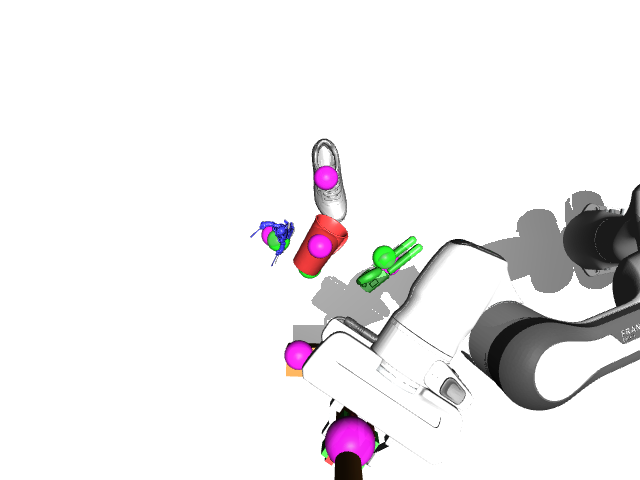

Green = ground truth, Magenta = estimated


In [165]:
# --- Reward test: visualize estimated vs. ground truth ---
if "perceptor_broom" not in globals():
    perceptor_broom = PerceptionModule(BROOM_WEIGHTS)

TARGET_POINT = np.array([0.0, 0.0, 0.0], dtype=np.float32)

# Render once and get detections.
rgb, depth, _ = _render_rgb_depth(robot_model, robot_data, camera="overhead_cam")
detections, _ = perceptor_broom.get_transforms(
    rgb, depth, model=robot_model, camera="overhead_cam"
 )

print("Detections:")
for det in detections:
    cls_name = det.get("class")
    conf = det.get("confidence")
    pos_world = det.get("position_world")
    print(f"- class={cls_name} conf={conf:.3f} pos_world={pos_world}")

# Collect ground-truth world positions for non-broom objects.
obj_names = ["mug", "can_opener", "action_fig", "shoe"]
gt_positions = {}
for name in obj_names:
    body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, name)
    gt_positions[name] = robot_data.xpos[body_id].copy()

print("Ground truth (world):")
for name, pos in gt_positions.items():
    print(f"- {name}: {pos}")

# Collect estimated positions (world) for non-broom detections.
est_positions = []
for det in detections:
    if det.get("class") == "broom":
        continue
    pos_world = det.get("position_world")
    if pos_world is None:
        continue
    est_positions.append(pos_world)

# Print reward for sanity.
print("Reward (sum distances):", reward(perceptor_broom, robot_model, robot_data, TARGET_POINT))

# Visualize GT vs estimated positions as colored spheres.
renderer_v = mujoco.Renderer(robot_model, 480, 640)
renderer_v.update_scene(robot_data, camera="overhead_cam")
scene = renderer_v.scene

# Ground truth: green spheres.
for pos in gt_positions.values():
    if scene.ngeom >= scene.maxgeom:
        break
    mujoco.mjv_initGeom(
        scene.geoms[scene.ngeom],
        mujoco.mjtGeom.mjGEOM_SPHERE, np.array([0.03, 0, 0]),
        pos, np.eye(3).flatten(), np.array([0.1, 0.9, 0.1, 0.8], dtype=np.float32)
    )
    scene.geoms[scene.ngeom].category = mujoco.mjtCatBit.mjCAT_DECOR
    scene.ngeom += 1

# Estimated: magenta spheres.
for pos in est_positions:
    if scene.ngeom >= scene.maxgeom:
        break
    mujoco.mjv_initGeom(
        scene.geoms[scene.ngeom],
        mujoco.mjtGeom.mjGEOM_SPHERE, np.array([0.03, 0, 0]),
        pos, np.eye(3).flatten(), np.array([0.9, 0.1, 0.9, 0.8], dtype=np.float32)
    )
    scene.geoms[scene.ngeom].category = mujoco.mjtCatBit.mjCAT_DECOR
    scene.ngeom += 1

viz_rgb = renderer_v.render()
media.show_image(viz_rgb)
print("Green = ground truth, Magenta = estimated")

In [166]:
# --- RL episode setup ---
OBJECT_NAMES = ["mug", "can_opener", "action_fig", "shoe"]


def _get_free_body_qpos_adr(model, body_name):
    body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body_name)
    if body_id < 0:
        return None
    jnt_adr = model.body_jntadr[body_id]
    if jnt_adr < 0:
        return None
    return int(model.jnt_qposadr[jnt_adr])


def scatter_objects(
    model,
    data,
    names,
    center_xy,
    half_span_xy,
    seed=None,
):
    rng = np.random.default_rng(seed)
    for name in names:
        qpos_adr = _get_free_body_qpos_adr(model, name)
        if qpos_adr is None:
            continue
        x = rng.uniform(center_xy[0] - half_span_xy[0], center_xy[0] + half_span_xy[0])
        y = rng.uniform(center_xy[1] - half_span_xy[1], center_xy[1] + half_span_xy[1])
        data.qpos[qpos_adr + 0] = float(x)
        data.qpos[qpos_adr + 1] = float(y)
    mujoco.mj_forward(model, data)


def apply_action(model, data, action, freeze_gripper=True, gripper_value=None):
    if model.nu == 0:
        return
    action = np.asarray(action, dtype=np.float32)
    if action.shape[0] != model.nu:
        raise ValueError(f"Expected action size {model.nu}, got {action.shape[0]}")
    data.ctrl[:] = action

    if freeze_gripper:
        gripper_act_ids = _get_gripper_actuator_ids(model, FINGER_JOINTS)
        if gripper_act_ids:
            if gripper_value is None:
                gripper_value = float(gripper_closed)
            for act_id in gripper_act_ids:
                data.ctrl[act_id] = float(gripper_value)


def reset_episode(
    model,
    data,
    object_names=OBJECT_NAMES,
    scatter_center=None,
    scatter_half=(0.2, 0.2),
    seed=None,
    settle_steps=120,
):
    if GRASP_START_QPOS is None:
        raise RuntimeError("Run the IK demo cell to capture GRASP_START_* before RL.")

    data.qpos[:] = GRASP_START_QPOS
    data.qvel[:] = 0.0
    if model.nu > 0:
        data.ctrl[:] = 0.0

    gripper_act_ids = _get_gripper_actuator_ids(model, FINGER_JOINTS)
    if gripper_act_ids:
        for act_id in gripper_act_ids:
            data.ctrl[act_id] = float(gripper_closed)

    if scatter_center is None:
        if GRASP_START_EE_POS is not None:
            scatter_center = GRASP_START_EE_POS[:2].copy()
        else:
            scatter_center = np.array([0.15, -0.2], dtype=np.float32)

    scatter_objects(model, data, object_names, scatter_center, scatter_half, seed=seed)

    if GRASP_START_ARM_QPOS is not None:
        settle_scene(model, data, arm_qpos=GRASP_START_ARM_QPOS, steps=settle_steps)
    else:
        settle_scene(model, data, arm_qpos=PANDA_READY, steps=settle_steps)

    return scatter_center


# --- Policy: MLP over proprioception + padded detections ---
# NOTE: Install PyTorch if missing: %pip install torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2


def _flatten_rot(mat3):
    return mat3.reshape(-1).astype(np.float32)


def encode_detections(detections, max_objects=6):
    # Sort by confidence, keep top-K, pad with zeros + mask.
    dets = sorted(detections, key=lambda d: float(d.get("confidence", 0.0)), reverse=True)
    dets = dets[:max_objects]

    feats = []
    mask = []
    for det in dets:
        pos = det.get("position_world")
        rot = det.get("rotation_world")
        conf = float(det.get("confidence", 0.0))
        if pos is None or rot is None:
            pos = np.zeros(3, dtype=np.float32)
            rot = np.eye(3, dtype=np.float32)
            conf = 0.0
        feat = np.concatenate([pos.astype(np.float32), _flatten_rot(rot), np.array([conf], dtype=np.float32)])
        feats.append(feat)
        mask.append(1.0)

    if len(feats) < max_objects:
        pad_count = max_objects - len(feats)
        feats.extend([np.zeros(3 + 9 + 1, dtype=np.float32) for _ in range(pad_count)])
        mask.extend([0.0] * pad_count)

    feats = np.stack(feats, axis=0)
    mask = np.array(mask, dtype=np.float32)
    return feats, mask


class PolicyNet(nn.Module):
    def __init__(self, proprio_dim, det_feat_dim, max_objects, action_dim, hidden=256):
        super().__init__()
        det_dim = det_feat_dim * max_objects + max_objects
        in_dim = proprio_dim + det_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)


class QNet(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + action_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, obs, action):
        x = torch.cat([obs, action], dim=-1)
        return self.net(x)


def build_observation(model, data, perceptor, camera="overhead_cam", max_objects=6, detections=None):
    proprio = data.qpos.copy().astype(np.float32)
    if detections is None:
        rgb, depth, _ = _render_rgb_depth(model, data, camera=camera)
        detections, _ = perceptor.get_transforms(rgb, depth, model=model, camera=camera)
    feats, mask = encode_detections(detections, max_objects=max_objects)
    flat = np.concatenate([proprio, feats.reshape(-1), mask], axis=0)
    return flat


def make_policy(model, action_scale=1.0, max_objects=6, hidden=256, device="cpu"):
    proprio_dim = model.nq
    det_feat_dim = 3 + 9 + 1
    action_dim = model.nu
    net = PolicyNet(proprio_dim, det_feat_dim, max_objects, action_dim, hidden=hidden).to(device)

    if action_dim > 0:
        torque_hi = model.actuator_forcerange[:, 1].astype(np.float32)
    else:
        torque_hi = np.zeros(0, dtype=np.float32)

    def policy_fn(obs, t):
        x = torch.from_numpy(obs).to(device)
        with torch.no_grad():
            action = net(x).cpu().numpy().astype(np.float32)
        if action_dim > 0:
            action = action * torque_hi * float(action_scale)
        return action

    return net, policy_fn


def run_episode(policy_fn, steps=200, reward_target=TARGET_POINT, max_objects=6, perception_stride=5):
    reset_episode(robot_model, robot_data)
    total_reward = 0.0
    last_detections = None
    for t in range(steps):
        if t % perception_stride == 0 or last_detections is None:
            rgb, depth, _ = _render_rgb_depth(robot_model, robot_data, camera="overhead_cam")
            last_detections, _ = perceptor_broom.get_transforms(rgb, depth, model=robot_model, camera="overhead_cam")
        obs = build_observation(robot_model, robot_data, perceptor_broom, max_objects=max_objects, detections=last_detections)
        action = policy_fn(obs, t)
        apply_action(robot_model, robot_data, action, freeze_gripper=True)
        mujoco.mj_step(robot_model, robot_data)
        total_reward += reward(perceptor_broom, robot_model, robot_data, reward_target, detections=last_detections)
    return total_reward


def run_policy_realtime(
    policy_fn,
    seconds=10.0,
    camera="overhead_cam",
    max_objects=6,
    window_name="Policy Rollout",
    perception_stride=5,
):
    reset_episode(robot_model, robot_data)
    renderer_rt = mujoco.Renderer(robot_model, 480, 640)
    dt = float(robot_model.opt.timestep)
    steps = int(max(1, seconds / max(dt, 1e-6)))

    last_detections = None
    for t in range(steps):
        if t % perception_stride == 0 or last_detections is None:
            rgb, depth, _ = _render_rgb_depth(robot_model, robot_data, camera=camera)
            last_detections, _ = perceptor_broom.get_transforms(rgb, depth, model=robot_model, camera=camera)
        obs = build_observation(robot_model, robot_data, perceptor_broom, max_objects=max_objects, detections=last_detections)
        action = policy_fn(obs, t)
        apply_action(robot_model, robot_data, action, freeze_gripper=True)
        mujoco.mj_step(robot_model, robot_data)

        renderer_rt.update_scene(robot_data, camera=camera)
        frame = renderer_rt.render()
        bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        cv2.imshow(window_name, bgr)
        if cv2.waitKey(1) & 0xFF == 27:
            break
        time.sleep(dt)

    cv2.destroyWindow(window_name)


# --- Off-policy training loop (DDPG-style) ---
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, action_dim):
        self.capacity = int(capacity)
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)
        self.size = 0
        self.ptr = 0

    def add(self, obs, action, reward, next_obs, done):
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            self.obs[idx],
            self.actions[idx],
            self.rewards[idx],
            self.next_obs[idx],
            self.dones[idx],
        )


def _soft_update(target, source, tau):
    for tp, sp in zip(target.parameters(), source.parameters()):
        tp.data.copy_(tp.data * (1.0 - tau) + sp.data * tau)


def _obs_dim(model, max_objects=6):
    proprio_dim = model.nq
    det_feat_dim = 3 + 9 + 1
    det_dim = det_feat_dim * max_objects + max_objects
    return proprio_dim + det_dim


def train_ddpg(
    episodes=50,
    steps_per_episode=200,
    batch_size=64,
    warmup=500,
    gamma=0.99,
    tau=0.01,
    noise_std=0.2,
    max_objects=6,
    hidden=256,
    device="cpu",
    log_every=200,
    perception_stride=5,
):
    obs_dim = _obs_dim(robot_model, max_objects=max_objects)
    action_dim = robot_model.nu
    if action_dim == 0:
        raise RuntimeError("No actuators available for training.")

    actor = PolicyNet(robot_model.nq, 3 + 9 + 1, max_objects, action_dim, hidden=hidden).to(device)
    critic = QNet(obs_dim, action_dim, hidden=hidden).to(device)
    actor_t = PolicyNet(robot_model.nq, 3 + 9 + 1, max_objects, action_dim, hidden=hidden).to(device)
    critic_t = QNet(obs_dim, action_dim, hidden=hidden).to(device)
    actor_t.load_state_dict(actor.state_dict())
    critic_t.load_state_dict(critic.state_dict())

    actor_opt = torch.optim.Adam(actor.parameters(), lr=1e-4)
    critic_opt = torch.optim.Adam(critic.parameters(), lr=3e-4)

    torque_hi = torch.from_numpy(robot_model.actuator_forcerange[:, 1].astype(np.float32)).to(device)
    buffer = ReplayBuffer(capacity=20000, obs_dim=obs_dim, action_dim=action_dim)

    total_steps = 0
    for ep in range(episodes):
        reset_episode(robot_model, robot_data)
        ep_return = 0.0
        last_detections = None
        for t in range(steps_per_episode):
            if t % perception_stride == 0 or last_detections is None:
                rgb, depth, _ = _render_rgb_depth(robot_model, robot_data, camera="overhead_cam")
                last_detections, _ = perceptor_broom.get_transforms(rgb, depth, model=robot_model, camera="overhead_cam")

            obs = build_observation(robot_model, robot_data, perceptor_broom, max_objects=max_objects, detections=last_detections)
            obs_t = torch.from_numpy(obs).to(device)
            with torch.no_grad():
                act = actor(obs_t).cpu().numpy().astype(np.float32)
            act = act * torque_hi.cpu().numpy()
            act += np.random.normal(scale=noise_std, size=act.shape).astype(np.float32)
            act = np.clip(act, -torque_hi.cpu().numpy(), torque_hi.cpu().numpy())

            apply_action(robot_model, robot_data, act, freeze_gripper=True)
            mujoco.mj_step(robot_model, robot_data)
            reward_val = reward(perceptor_broom, robot_model, robot_data, TARGET_POINT, detections=last_detections)
            ep_return += float(reward_val)

            # Re-read next_obs, using the same last_detections (the network doesn't receive the *updated* object positions for the DDPG next_obs until the next stride anyway,
            # this works functionally as the observation during this step's tick).
            if (t + 1) % perception_stride == 0:
                rgb, depth, _ = _render_rgb_depth(robot_model, robot_data, camera="overhead_cam")
                next_detections, _ = perceptor_broom.get_transforms(rgb, depth, model=robot_model, camera="overhead_cam")
            else:
                next_detections = last_detections

            next_obs = build_observation(robot_model, robot_data, perceptor_broom, max_objects=max_objects, detections=next_detections)
            done = float(t == steps_per_episode - 1)
            buffer.add(obs, act, reward_val, next_obs, done)

            total_steps += 1
            if log_every and total_steps % int(log_every) == 0:
                print(
                    f"Step {total_steps} | ep {ep + 1}/{episodes} | t {t + 1}/{steps_per_episode} | return {ep_return:.3f}"
                )

            if buffer.size >= warmup:
                b_obs, b_act, b_rew, b_next, b_done = buffer.sample(batch_size)
                b_obs = torch.from_numpy(b_obs).to(device)
                b_act = torch.from_numpy(b_act).to(device)
                b_rew = torch.from_numpy(b_rew).to(device)
                b_next = torch.from_numpy(b_next).to(device)
                b_done = torch.from_numpy(b_done).to(device)

                with torch.no_grad():
                    next_act = actor_t(b_next) * torque_hi
                    q_target = b_rew + gamma * (1.0 - b_done) * critic_t(b_next, next_act)

                q_val = critic(b_obs, b_act)
                critic_loss = F.mse_loss(q_val, q_target)
                critic_opt.zero_grad()
                critic_loss.backward()
                critic_opt.step()

                actor_loss = -critic(b_obs, actor(b_obs) * torque_hi).mean()
                actor_opt.zero_grad()
                actor_loss.backward()
                actor_opt.step()

                _soft_update(actor_t, actor, tau)
                _soft_update(critic_t, critic, tau)

        print(f"Episode {ep + 1}: return={ep_return:.3f}")

    return actor, critic


# Example usage:
actor, critic = train_ddpg(episodes=20, steps_per_episode=100, warmup=200, log_every=50, perception_stride=50)
net, policy_fn = make_policy(robot_model, action_scale=1.0)
net.load_state_dict(actor.state_dict())
episode_return = run_episode(policy_fn, steps=200, perception_stride=50)
print("Eval return:", episode_return)
run_policy_realtime(policy_fn, seconds=10.0, perception_stride=50)

Step 50 | ep 1/20 | t 50/100 | return -155.785
Step 100 | ep 1/20 | t 100/100 | return -312.061
Episode 1: return=-312.061
Step 150 | ep 2/20 | t 50/100 | return -158.963
Step 200 | ep 2/20 | t 100/100 | return -312.403
Episode 2: return=-312.403
Step 250 | ep 3/20 | t 50/100 | return -155.031
Step 300 | ep 3/20 | t 100/100 | return -309.679
Episode 3: return=-309.679
Step 350 | ep 4/20 | t 50/100 | return -151.240
Step 400 | ep 4/20 | t 100/100 | return -302.157
Episode 4: return=-302.157
Step 450 | ep 5/20 | t 50/100 | return -161.418
Step 500 | ep 5/20 | t 100/100 | return -327.536
Episode 5: return=-327.536
Step 550 | ep 6/20 | t 50/100 | return -153.119
Step 600 | ep 6/20 | t 100/100 | return -316.272
Episode 6: return=-316.272
Step 650 | ep 7/20 | t 50/100 | return -154.129
Step 700 | ep 7/20 | t 100/100 | return -310.152
Episode 7: return=-310.152
Step 750 | ep 8/20 | t 50/100 | return -158.686
Step 800 | ep 8/20 | t 100/100 | return -331.471
Episode 8: return=-331.471
Step 850 

KeyboardInterrupt: 